<a href="https://colab.research.google.com/github/roberturena20/daily-news-email/blob/main/TFM_EAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introducción

El abandono escolar y el fracaso educativo plantean desafíos importantes para el crecimiento económico y el bienestar social, y afectan directamente a los estudiantes, las familias, las instituciones y la comunidad en general. Según [Education Data Initiative](https://educationdata.org/college-dropout-rates#:~:text=Report%20Highlights.,Enrollment%20Statistics%20%7C%20Financial%20Aid%20Statistics), alrededor del 40% de los estudiantes universitarios abandonan sus estudios antes de completar su título. Los que abandonan la universidad enfrentan más desafíos financieros, ya que ganan un promedio de 35% menos de ingresos y experimentan una tasa de desempleo 20% más alta en comparación con sus compañeros que se gradúan.

En este proyecto, mi objetivo es construir un modelo de clasificación para predecir el abandono escolar de los estudiantes e identificar qué estudiantes necesitan más apoyo para evitar que lo hagan.

**Preguntas de investigación:**

* ¿Qué factores contribuyen al abandono escolar de los estudiantes y cómo lo afectan?
* ¿Qué estudiantes necesitan más apoyo para permanecer en la escuela?

**Datos**

El conjunto de datos contiene 4.424 registros con 35 atributos, donde cada registro representa a un estudiante individual. Incluye información disponible en el momento de la inscripción del estudiante, junto con datos demográficos, socioeconómicos y macroeconómicos, así como el desempeño académico de los estudiantes al final del primer y segundo semestre.

* **Fuente de los datos:** Valentim Realinho, Jorge Machado, Luís Baptista y Mónica V. Martins. “Predict Students' Dropout and Academic Success”. Zenodo, 13 de diciembre de 2021. https://doi.org/10.5281/zenodo.5777340.

* **Descripción de los datos:** Realinho, Valentim, Jorge Machado, Luís Baptista y Mónica V. Martins. 2022. "Predicting Student Dropout and Academic Success" Data 7, no. 11: 146. https://doi.org/10.3390/data7110146

In [12]:
# Cargamos los paquetes
from google.colab import files
print("📁 Selecciona tu archivo CSV...")
uploaded = files.upload()

# Obtener el nombre del archivo
filename = list(uploaded.keys())[0]
print(f"✅ Archivo cargado: {filename}")

# Ahora cargar con pandas
import pandas as pd
students = pd.read_csv(filename)
students.info()

📁 Selecciona tu archivo CSV...


Saving Student performance (Polytechnic Institute of Portalegre).csv to Student performance (Polytechnic Institute of Portalegre) (5).csv
✅ Archivo cargado: Student performance (Polytechnic Institute of Portalegre) (5).csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4

# Limpieza de datos

Este conjunto de datos está prácticamente limpio gracias al riguroso preprocesamiento de datos realizado por los contribuyentes de los datos ([Referencia](https://www.mdpi.com/2306-5729/7/11/146)). Se han ocupado de anomalías, valores atípicos y valores faltantes.

Sin embargo, todavía se necesitan algunos pasos de limpieza menores. Primero, modificaré algunos nombres de columnas para que sean más consistentes y sea más fácil trabajar con ellos más adelante.

In [13]:
# Corrija un nombre de columna que tenga un error tipográfico y reemplace las comillas simples con guiones bajos
students.rename(columns = {"Nacionality": "Nationality",
                           "Mother's qualification": "Mother_qualification",
                           "Father's qualification": "Father_qualification",
                           "Mother's occupation": "Mother_occupation",
                           "Father's occupation": "Father_occupation",
                           "Age at enrollment": "Age"}, inplace = True)

# Reemplace los espacios en blanco en los nombres de las columnas con guiones bajos
students.columns = students.columns.str.replace(' ', '_')

#Eliminar el paréntesis
students.columns = students.columns.str.replace('(', '')
students.columns = students.columns.str.replace(')', '')

I'll change the data types of columns that should be categorical from ‘int’ to ‘category’ to ensure that classification models treat these columns as categorical data rather than numerical.

In [14]:
# Cambiar los tipos de datos de las columnas que deben ser categóricas
col = ['Marital_status', 'Application_mode', 'Application_order', 'Course',
      'Daytime/evening_attendance', 'Previous_qualification', 'Nationality',
       'Mother_qualification', 'Father_qualification', 'Mother_occupation',
       'Father_occupation', 'Displaced', 'Educational_special_needs', 'Debtor',
       'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder',
      'International', 'Target']

students[col] = students[col].astype('category')

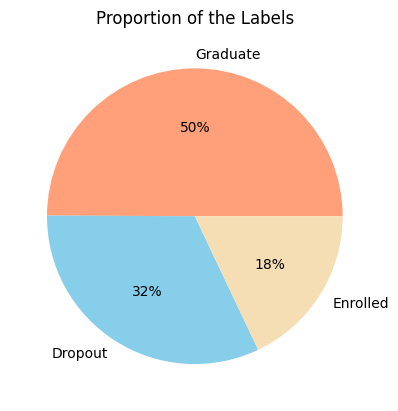

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Ahora tu código
labels = students['Target'].value_counts().index
values = students['Target'].value_counts().values

plt.pie(values, labels=labels, colors=['lightsalmon', 'skyblue', 'wheat'], autopct='%1.0f%%')
plt.title('Proportion of the Labels')
plt.show()

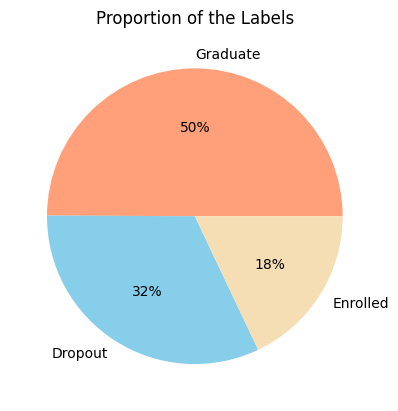

In [17]:
# Verificar la proporción de las etiquetas en la variable de destino
labels = students['Target'].value_counts().index
values = students['Target'].value_counts().values

plt.pie(values, labels = labels, colors = ['lightsalmon', 'skyblue', 'wheat'], autopct = '%1.0f%%')
plt.title('Proportion of the Labels');

From the pie chart above we can see that the data is imbalanced: with about 50% of the labels are 'Graduate', 32% are 'Dropout', and 18% are 'Enrolled'.

The labels are string, I will encode them as ordinal data -- 0 represents 'Dropout', 1 represents 'Enrolled', and 2 represents 'Graduate' -- since most classification models only handle numeric values.

In [18]:
from sklearn.preprocessing import OrdinalEncoder

# Codifique las etiquetas como datos ordinales (0 - 'Abandono', 1 - 'Inscrito' y 2 - 'Graduado')
students['Target_encoded'] = OrdinalEncoder(categories = [['Dropout', 'Enrolled', 'Graduate']]).fit_transform(students[['Target']])

# Eliminar la variable 'Target'
students.drop('Target', axis = 1, inplace = True)

# Exploratory Data Analysis

There are 34 features in this dataset. I will examine their relationship with the target variable, which is a three-class categorical data. The features that have no association with the label will be the potential variables to be removed from modeling.

**Chi-Square Independence Test for Categorical Variables**

The Chi-Square independence test will be implemented to check the association between the categorical variables and the dependent variable, with the hypothesis as follows:  

$H_{0}$: the two variables are independent  
$H_{1}$: the two variables are dependent  

$\alpha$ = 0.05

I will reject the null hypothesis and accept the alternative hypothesis if the p-value is less than 0.05, meaning the two variables are dependent. If the p-value is greater than or equal to 0.05, I fail to reject the null hypothesis, meaning the two variables are independent.

In [19]:
from scipy.stats import chi2_contingency

# lista de características categóricas
cats = ['Marital_status', 'Application_mode', 'Application_order',
        'Course','Daytime/evening_attendance', 'Previous_qualification',
        'Nationality','Mother_qualification', 'Father_qualification',
        'Mother_occupation', 'Father_occupation', 'Displaced',
        'Educational_special_needs', 'Debtor','Tuition_fees_up_to_date',
        'Gender', 'Scholarship_holder','International']

# Obtener los valores p de las pruebas de independencia de Chi-Cuadrado
p_value = []

for col in cats:
    crosstable = pd.crosstab(index = students[col],
                             columns = students['Target_encoded'])
    p = chi2_contingency(crosstable)[1]
    p_value.append(p)

chi2_result = pd.DataFrame({
    'Variable': cats,
    'P_value': [round(ele, 5) for ele in p_value]
})

chi2_result = chi2_result.sort_values('P_value')

chi2_result

,Variable,P_value
0,Marital_status,0.00000
1,Application_mode,0.00000
2,Application_order,0.00000
3,Course,0.00000
4,Daytime/evening_attendance,0.00000
5,Previous_qualification,0.00000
7,Mother_qualification,0.00000
8,Father_qualification,0.00000
13,Debtor,0.00000
9,Mother_occupation,0.00000


La mayoría de los valores p son cercanos a cero, excepto para tres variables ('Nacionalidad', 'Internacional', 'Necesidades educativas especiales') con valores p muy altos (0,24, 0,53, 0,73), lo que indica que no hay asociación estadísticamente significativa entre estas tres características y la etiqueta. Las excluiré del modelo.

In [20]:
stud_selected = students.drop(['Nationality', 'International', 'Educational_special_needs'],
                              axis = 1)

**Correlación de rango de Spearman entre características numéricas y la etiqueta**

Se utiliza un mapa de calor para visualizar la correlación de rango de Spearman entre características numéricas y las etiquetas. La correlación de rango de Spearman mide la fuerza y ​​la dirección de la asociación monótona entre dos variables. Puede capturar relaciones monótonas tanto lineales como no lineales.

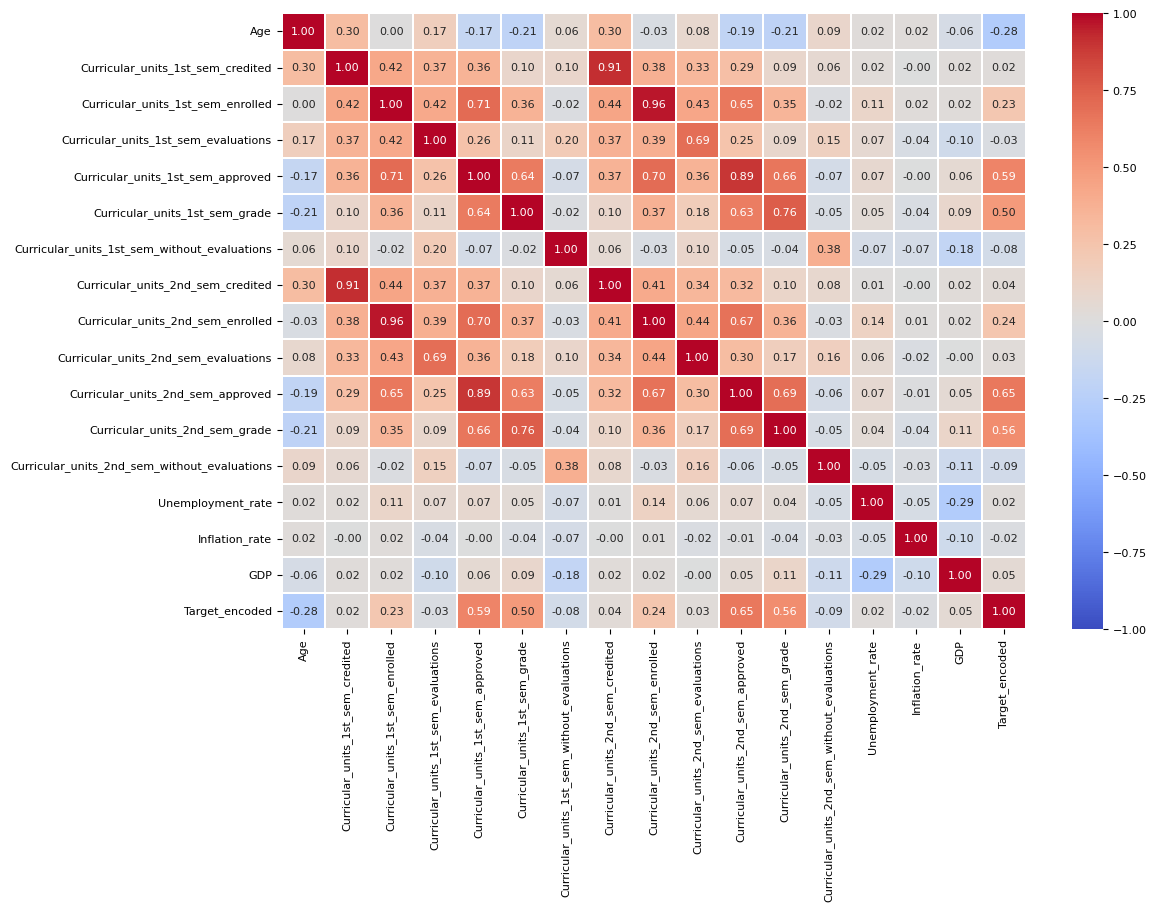

In [21]:
# Características numéricas
num_features = students[['Age',
       'Curricular_units_1st_sem_credited',
       'Curricular_units_1st_sem_enrolled',
       'Curricular_units_1st_sem_evaluations',
       'Curricular_units_1st_sem_approved',
       'Curricular_units_1st_sem_grade',
       'Curricular_units_1st_sem_without_evaluations',
       'Curricular_units_2nd_sem_credited',
       'Curricular_units_2nd_sem_enrolled',
       'Curricular_units_2nd_sem_evaluations',
       'Curricular_units_2nd_sem_approved',
       'Curricular_units_2nd_sem_grade',
       'Curricular_units_2nd_sem_without_evaluations',
       'Unemployment_rate', 'Inflation_rate', 'GDP', 'Target_encoded']]

# Mapa de calor de la matriz de correlación
plt.figure(figsize = (12, 8))
plt.rcParams.update({'font.size': 8})
hm = sns.heatmap(num_features.corr(method = 'spearman'),
                 cmap = 'coolwarm', annot = True, fmt = '.2f',
                 linewidths = .2, vmin = -1, vmax = 1, center = 0)

Como se puede observar en el mapa de calor, hay cuatro características ('Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade') que tienen correlaciones relativamente altas y positivas con la etiqueta, mientras que algunas tienen correlaciones muy bajas (por ejemplo, 'Unemployment_rate', 'Inflation_rate')

El mapa de calor también revela multicolinealidad entre las características relacionadas con las unidades curriculares. Estas características representan el desempeño académico de los estudiantes al final del primer y segundo semestre. Las agregaré para obtener el valor promedio entre los dos semestres.

In [23]:
# Promedio de datos de rendimiento académico a lo largo de dos semestres
stud_selected['curri_avg_credited'] = stud_selected[['Curricular_units_1st_sem_credited', 'Curricular_units_2nd_sem_credited']].mean(axis = 1)
stud_selected['curri_avg_enrolled'] = stud_selected[['Curricular_units_1st_sem_enrolled', 'Curricular_units_2nd_sem_enrolled']].mean(axis = 1)
stud_selected['curri_avg_evaluations'] = stud_selected[['Curricular_units_1st_sem_evaluations', 'Curricular_units_2nd_sem_evaluations']].mean(axis = 1)
stud_selected['curri_avg_approved'] = stud_selected[['Curricular_units_1st_sem_approved', 'Curricular_units_2nd_sem_approved']].mean(axis = 1)
stud_selected['curri_avg_grade'] = stud_selected[['Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_grade']].mean(axis = 1)
stud_selected['curri_avg_without_evaluations'] = stud_selected[['Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_without_evaluations']].mean(axis = 1)

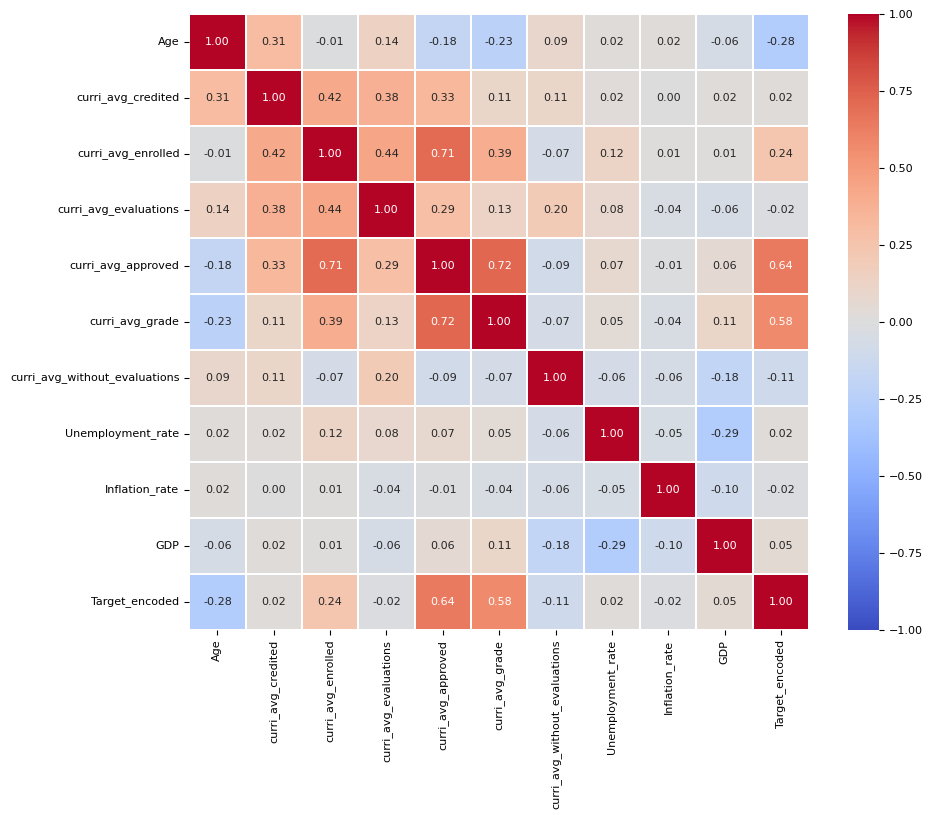

In [24]:
# Dibujamos nuevamente el mapa de calor de la matriz de correlación
num_features = stud_selected[['Age', 'curri_avg_credited', 'curri_avg_enrolled',
                              'curri_avg_evaluations', 'curri_avg_approved',
                              'curri_avg_grade', 'curri_avg_without_evaluations',
                              'Unemployment_rate', 'Inflation_rate',
                              'GDP', 'Target_encoded']]

plt.figure(figsize = (10, 8))
plt.rcParams.update({'font.size': 8})
sns.heatmap(num_features.corr(method = 'spearman'), vmin = -1, vmax = 1, center = 0,
            cmap = 'coolwarm', fmt = '.2f', linewidths = .2, annot = True);

La nueva matriz de correlación anterior muestra que 'curri_avg_approved' y 'curri_avg_grade' todavía tienen una correlación relativamente alta con las etiquetas ('Target_encoded'), mientras que 'curri_avg_credited' y 'curri_avg_evaluations', junto con los datos macroeconómicos ('Unemployment_rate', 'Inflation_rate'), tienen correlaciones muy bajas, todas entre -0,02 y 0,02. Excluiré estas cuatro características.

La multicolinealidad todavía existe entre los datos académicos. La tendré en cuenta al seleccionar los modelos.

Veamos cómo 'curri_avg_approved' y 'curri_avg_grade' se asocian con la situación de los estudiantes al final de la duración normal del curso.

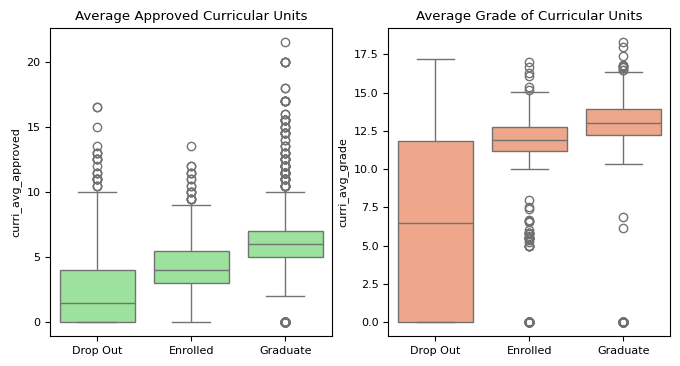

In [25]:
# Grafica 'curri_avg_approved' y 'curri_avg_grade' vs. Target
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (8, 4))
sns.boxplot(data = stud_selected, x = 'Target_encoded', y = 'curri_avg_approved',
            color = 'lightgreen', ax = ax1)
ax1.set_title('Average Approved Curricular Units')
ax1.set_xlabel("")
ax1.set_xticks([0, 1, 2])
ax1.set_xticklabels(['Drop Out', 'Enrolled', 'Graduate']);

sns.boxplot(data = stud_selected, x = 'Target_encoded', y = 'curri_avg_grade',
            color = 'lightsalmon', ax = ax2)
ax2.set_title('Average Grade of Curricular Units')
ax2.set_xlabel("")
ax2.set_xticks([0, 1, 2])
ax2.set_xticklabels(['Drop Out', 'Enrolled', 'Graduate']);

No es de extrañar que “Posgrado” se asocie con más unidades curriculares aprobadas y calificaciones más altas. Sin embargo, hay algunos casos de un valor 0 para la calificación promedio y el promedio de unidades curriculares aprobadas en la clase “Posgrado”.

In [26]:
# Marcar las filas con promedio cero de unidades curriculares aprobadas y estudiantes en proceso de graduación.
stud_selected.loc[(stud_selected['curri_avg_approved'] == 0) & (stud_selected['Target_encoded'] == 2)]

,Marital_status,Application_mode,Application_order,Course,Daytime/evening_attendance,Previous_qualification,Previous_qualification_grade,Mother_qualification,Father_qualification,Mother_occupation,...,Unemployment_rate,Inflation_rate,GDP,Target_encoded,curri_avg_credited,curri_avg_enrolled,curri_avg_evaluations,curri_avg_approved,curri_avg_grade,curri_avg_without_evaluations
20,1,1,3,171,1,1,122.0,1,1,9,...,11.1,0.6,2.02,2.0,0.0,0.0,0.0,0.0,0.0,0.0
66,1,1,3,171,1,1,139.0,19,19,5,...,10.8,1.4,1.74,2.0,0.0,0.0,0.0,0.0,0.0,0.0
101,1,1,4,171,1,1,133.1,1,1,9,...,16.2,0.3,-0.92,2.0,0.0,0.0,0.0,0.0,0.0,0.0
405,1,1,1,171,1,1,135.0,1,19,3,...,12.7,3.7,-1.70,2.0,0.0,0.0,0.0,0.0,0.0,0.0
527,1,39,1,171,1,1,145.0,3,1,2,...,9.4,-0.8,-3.12,2.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3946,1,17,2,171,1,1,142.0,3,1,2,...,15.5,2.8,-4.06,2.0,0.0,0.0,0.0,0.0,0.0,0.0
4291,1,1,1,171,1,1,137.0,1,38,4,...,15.5,2.8,-4.06,2.0,0.0,0.0,0.0,0.0,0.0,0.0
4353,1,1,1,171,1,1,141.0,3,1,4,...,12.4,0.5,1.79,2.0,0.0,0.0,0.0,0.0,0.0,0.0
4365,1,1,2,171,1,1,117.0,38,38,4,...,7.6,2.6,0.32,2.0,0.0,0.0,0.0,0.0,0.0,0.0


Hay 75 puntos de datos en los que todos los datos relacionados con las unidades curriculares son cero, pero los estudiantes están etiquetados como "Graduados". Esto contradice el sentido común. Trataré estas filas como valores atípicos y las eliminaré del conjunto de datos.

In [27]:
# Eliminamos los outliers
stud_selected = stud_selected.drop(stud_selected.loc[(stud_selected['curri_avg_approved'] == 0) & (stud_selected['Target_encoded'] == 2)].index)

# Marque las filas con calificación promedio cero y estudiantes que se gradúan
stud_selected.loc[(stud_selected['curri_avg_grade'] == 0) & (stud_selected['Target_encoded'] == 2)]

,Marital_status,Application_mode,Application_order,Course,Daytime/evening_attendance,Previous_qualification,Previous_qualification_grade,Mother_qualification,Father_qualification,Mother_occupation,...,Unemployment_rate,Inflation_rate,GDP,Target_encoded,curri_avg_credited,curri_avg_enrolled,curri_avg_evaluations,curri_avg_approved,curri_avg_grade,curri_avg_without_evaluations


Hay 0 filas con calificación promedio 0 y estudiantes graduados, lo que significa que el valor 0 para la calificación promedio y las unidades curriculares aprobadas promedio en la clase 'Graduados' corresponden a los mismos puntos de datos.

In [28]:
# Eliminar las funciones no seleccionadas junto con las funciones que se han agregado en otras nuevas
stud_selected = stud_selected.drop(columns = ['Unemployment_rate', 'Inflation_rate',
                                              'curri_avg_credited', 'curri_avg_evaluations',
                                              'Curricular_units_1st_sem_credited',
                                              'Curricular_units_1st_sem_enrolled',
                                              'Curricular_units_1st_sem_evaluations',
                                              'Curricular_units_1st_sem_approved',
                                              'Curricular_units_1st_sem_grade',
                                              'Curricular_units_1st_sem_without_evaluations',
                                              'Curricular_units_2nd_sem_credited',
                                              'Curricular_units_2nd_sem_enrolled',
                                              'Curricular_units_2nd_sem_evaluations',
                                              'Curricular_units_2nd_sem_approved',
                                              'Curricular_units_2nd_sem_grade',
                                              'Curricular_units_2nd_sem_without_evaluations'])

# Modelado

**Modelos**

En función de las características del conjunto de datos (clasificación multiclase, aproximadamente el 50 % de datos categóricos, clases desequilibradas y multicolinealidad), Random Forest y XGBoost son modelos candidatos sólidos. Se sabe que manejan bien estas características y pueden lograr un buen rendimiento en problemas similares.

**Métricas de evaluación**

Debido a la naturaleza desequilibrada del conjunto de datos, emplearé la precisión equilibrada (la recuperación promedio obtenida para cada clase), la puntuación F1 (la media armónica de precisión y recuperación) y el AUC (el área bajo la curva ROC, que representa gráficamente la tasa de verdaderos positivos frente a la tasa de falsos positivos) como métricas de evaluación.

In [29]:
from sklearn.model_selection import train_test_split

# Dividir los datos en conjuntos de entrenamiento y prueba
train, test = train_test_split(stud_selected, test_size = 0.2,
                               stratify = stud_selected['Target_encoded'], random_state = 0)

# Extraer características y etiquetas
train_features = train.drop('Target_encoded', axis = 1)
train_labels = train['Target_encoded']
test_features = test.drop('Target_encoded', axis = 1)
test_labels = test['Target_encoded']

**Primera iteración de modelado (21 características, etiqueta de 3 clases)**

Entrenaré los modelos Random Forest y XGBoost por separado como modelos base (‘rf_base’, ‘xgb_base’), ajustaré sus hiperparámetros utilizando RandomizedSearchCV con la validación cruzada de 5 pasos predeterminada (‘tuned_rf’, ‘tuned_xgb’), combinaré los dos modelos con mejor rendimiento de los cuatro anteriores utilizando VotingClassifier (‘vc_soft’) y compararé el rendimiento de los cinco modelos.


In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score

# Entrene el bosque aleatorio en el conjunto de entrenamiento, configure 'class_weight' como 'balanced'
#para ajustar los pesos de nuestros datos desequilibrados.
rf_base = RandomForestClassifier(class_weight = 'balanced', random_state = 42)
rf_base.fit(train_features, train_labels)

y_pred = rf_base.predict(test_features)
y_prob = rf_base.predict_proba(test_features)

rf_base_accuracy = round(balanced_accuracy_score(test_labels, y_pred), 3)
rf_base_f1score = round(f1_score(test_labels, y_pred, average = 'macro'), 3)
rf_base_auc = round(roc_auc_score(test_labels, y_prob, average = 'macro', multi_class = 'ovr'), 3)

print('Random Forest Baseline Performance:')
print('Balanced Accuracy:', rf_base_accuracy)
print('F1 Score:', rf_base_f1score)
print('AUC score:', rf_base_auc)

Random Forest Baseline Performance:
Balanced Accuracy: 0.703
F1 Score: 0.716
AUC score: 0.897


In [31]:
from sklearn.model_selection import RandomizedSearchCV

# Crear la cuadrícula de parámetros
parm = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 4, 5],
    'max_samples': [0.5, 0.75, 1]
}

# Tuneamos los parametros del Randon Forest
rsv_rf = RandomizedSearchCV(estimator = RandomForestClassifier(class_weight = 'balanced', random_state = 42),
                            param_distributions = parm, scoring = 'balanced_accuracy',
                            n_iter = 30, n_jobs = -1,  random_state = 0)

rsv_rf.fit(train_features, train_labels)

# Obtenga el mejor estimador
tuned_rf = rsv_rf.best_estimator_

# Verificar el rendimiento del modelo
y_pred = tuned_rf.predict(test_features)
y_prob = tuned_rf.predict_proba(test_features)

tuned_rf_accuracy = round(balanced_accuracy_score(test_labels, y_pred), 3)
tuned_rf_f1score = round(f1_score(test_labels, y_pred, average = 'macro'), 3)
tuned_rf_auc = round(roc_auc_score(test_labels, y_prob, average = 'macro', multi_class = 'ovr'), 3)

print('Tuned Random Forest Performance:')
print('Balanced Accuracy:', tuned_rf_accuracy)
print('F1 Score:', tuned_rf_f1score)
print('AUC score:', tuned_rf_auc)

Tuned Random Forest Performance:
Balanced Accuracy: 0.711
F1 Score: 0.718
AUC score: 0.896


In [32]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Entrene a XGBClassifier en el conjunto de entrenamiento con sample_weight ajustado
sample_weights = compute_sample_weight(class_weight='balanced', y = train_labels)
xgb_base = XGBClassifier(enable_categorical = True, objective = 'multi:softmax',
                         num_class = 3, random_state = 42)
xgb_base.fit(train_features, train_labels, sample_weight=sample_weights)

y_pred = xgb_base.predict(test_features)
y_prob = xgb_base.predict_proba(test_features)

xgb_base_accuracy = round(balanced_accuracy_score(test_labels, y_pred), 3)
xgb_base_f1score = round(f1_score(test_labels, y_pred, average = 'macro'), 3)
xgb_base_auc = round(roc_auc_score(test_labels, y_prob, average = 'macro', multi_class = 'ovr'), 3)

print('XGBoost baseline performance:')
print('Balanced accuracy:', xgb_base_accuracy)
print('F1 score:', xgb_base_f1score)
print('AUC score:', xgb_base_auc)

XGBoost baseline performance:
Balanced accuracy: 0.742
F1 score: 0.752
AUC score: 0.895


In [33]:
# Ajuste los hiperparámetros de XGBClassifier
param = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.05, 0.1, 0.2, 0.3],
    'max_depth': [3, 6, 10],
    'min_child_weight': [1, 5, 7],
    'subsample': [0.5, 0.75, 1],
    'colsample_bytree': [0.5, 0.75, 1],
    'gamma': [0, 0.5, 0.8]
}

rsv_xgb = RandomizedSearchCV(estimator = XGBClassifier(enable_categorical = True, objective = 'multi:softmax',
                                                       num_class = 3, random_state = 42),
                             param_distributions = param, scoring = 'balanced_accuracy',
                             n_iter= 50, n_jobs = -1, random_state = 1)

rsv_xgb.fit(train_features, train_labels, sample_weight=sample_weights)

# Obtener el mejor estimador
tuned_xgb = rsv_xgb.best_estimator_

# Verificar el rendimiento del modelo
y_pred = tuned_xgb.predict(test_features)
y_prob = tuned_xgb.predict_proba(test_features)

tuned_xgb_accuracy = round(balanced_accuracy_score(test_labels, y_pred), 3)
tuned_xgb_f1score = round(f1_score(test_labels, y_pred, average = 'macro'), 3)
tuned_xgb_auc = round(roc_auc_score(test_labels, y_prob, average = 'macro', multi_class = 'ovr'), 3)

print('Tuned XGBoost performance:')
print('Balanced accuracy:', tuned_xgb_accuracy)
print('F1 score:', tuned_xgb_f1score)
print('AUC score:', tuned_xgb_auc)


Tuned XGBoost performance:
Balanced accuracy: 0.741
F1 score: 0.74
AUC score: 0.9


In [34]:
from sklearn.ensemble import VotingClassifier

# Combine modelos ajustados por VotingClassifier
vc_soft = VotingClassifier(estimators = [('rf', tuned_rf), ('xgb', xgb_base)], voting = 'soft')
vc_soft.fit(train_features, train_labels)

y_pred = vc_soft.predict(test_features)
y_prob = vc_soft.predict_proba(test_features)

vc_soft_accuracy = round(balanced_accuracy_score(test_labels, y_pred), 3)
vc_soft_f1score = round(f1_score(test_labels, y_pred, average = 'macro'), 3)
vc_soft_auc = round(roc_auc_score(test_labels, y_prob, average = 'macro', multi_class = 'ovr'), 3)

print('vc_soft performance:')
print('Balanced accuracy:', vc_soft_accuracy)
print('F1 score:', vc_soft_f1score)
print('AUC score:', vc_soft_auc)

vc_soft performance:
Balanced accuracy: 0.736
F1 score: 0.748
AUC score: 0.904


In [35]:
# Cree un marco de datos 'rendimiento' para almacenar los resultados de rendimiento de los cinco modelos
performance = pd.DataFrame({
            'Model': ['rf_base', 'tuned_rf', 'xgb_base', 'tuned_xgb', 'vc_soft'],
            'Balanced Accuracy': [rf_base_accuracy, tuned_rf_accuracy, xgb_base_accuracy, tuned_xgb_accuracy, vc_soft_accuracy],
            'F1 Score': [rf_base_f1score, tuned_rf_f1score, xgb_base_f1score, tuned_xgb_f1score, vc_soft_f1score],
            'AUC': [rf_base_auc, tuned_rf_auc, xgb_base_auc, tuned_xgb_auc, vc_soft_auc]
            })

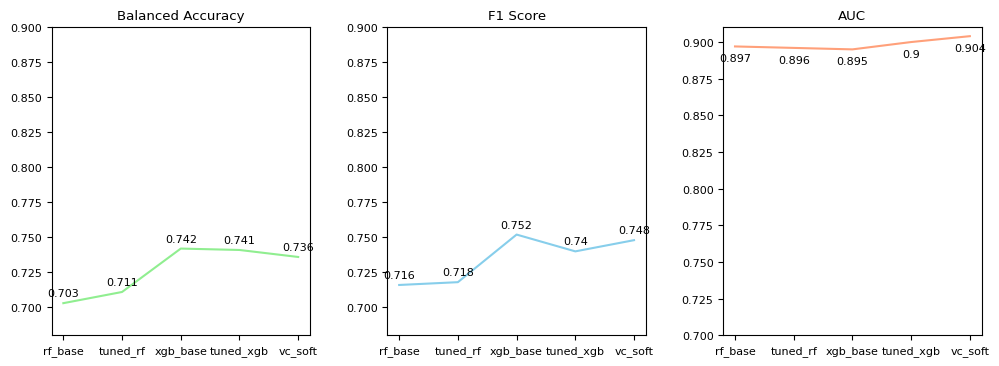

In [36]:
# Grafique el rendimiento de los cinco modelos
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 4))
plt.subplots_adjust(wspace = 0.3)

# Extraer x-ticks y el nombre de los modelos
x_ticks = range(len(performance['Model']))
models = performance['Model'].to_list()

# Graficar Balanced Accuracy
axs[0].plot(x_ticks, performance['Balanced Accuracy'], linestyle = '-', color = 'lightgreen')
axs[0].set_title('Balanced Accuracy')
axs[0].set_xticks(x_ticks)
axs[0].set_xticklabels(models)
axs[0].set_ylim(0.68, 0.9)
y1 = performance['Balanced Accuracy'].to_list()
for i, y in enumerate(y1):
    axs[0].text(i, y+0.005, f'{y}', ha = 'center')

# Graficar F1 Score
axs[1].plot(x_ticks, performance['F1 Score'], linestyle = '-', color = 'skyblue')
axs[1].set_title('F1 Score')
axs[1].set_xticks(x_ticks)
axs[1].set_xticklabels(models)
axs[1].set_ylim(0.68,0.9)
y2 = performance['F1 Score'].to_list()
for i, y in enumerate(y2):
    axs[1].text(i, y+0.005, f'{y}', ha = 'center')

# Graficar AUC Score
axs[2].plot(x_ticks, performance['AUC'], linestyle = '-', color = 'lightsalmon')
axs[2].set_title('AUC')
axs[2].set_xticks(x_ticks)
axs[2].set_xticklabels(models)
axs[2].set_ylim(0.70, 0.91)
y3 = performance['AUC'].to_list()
for i, y in enumerate(y3):
    axs[2].text(i, y-0.01, f'{y}', ha = 'center')

En los gráficos de rendimiento anteriores, podemos ver que 'xgb_base' y 'vc_soft' tienen un mejor rendimiento que los demás. El rendimiento de estos dos modelos es muy similar: tienen el mismo puntaje F1; 'xgb_base' tiene un rendimiento un poco mejor en precisión equilibrada y 'vc_soft' tiene un rendimiento un poco mejor en AUC.

También es notable que los puntajes AUC en todos los modelos son mucho más altos que la precisión equilibrada y el puntaje F1. Esto puede indicar un problema potencial con la capacidad del modelo para predecir una determinada clase con precisión.

Comprobemos la matriz de confusión de 'xgb_base' y veamos qué podemos encontrar.

In [37]:
from sklearn.metrics import confusion_matrix
pd.DataFrame(confusion_matrix(test_labels, xgb_base.predict(test_features)))

,0,1,2
0,222,33,29
1,30,82,47
2,14,16,397


Parece que el modelo es mejor para distinguir entre las clases 0 y 2, pero es menos preciso para distinguir entre las clases 1 y 2, o 1 y 0. Esto tiene sentido porque la clase 0 representa "Abandono", la clase 2 representa "Graduado" y la clase 1 representa "Inscrito", que es un estado intermedio que puede pasar a "Abandono" o "Graduado" más adelante. En este sentido, el estado intermedio puede introducir ruido en el modelo y afectar su rendimiento.

**Segunda iteración del modelado (21 características, etiqueta binaria)**

Como se mencionó anteriormente, nuestro objetivo en este proyecto es predecir el abandono escolar de los estudiantes e identificar qué estudiantes necesitan más apoyo. Teniendo en cuenta esto, ¿un modelo de clasificación binaria con solo dos etiquetas, "Abandono" y "Graduado", tendrá un mejor rendimiento?

Para averiguarlo, eliminaré la clase intermedia ('Inscrito') y entrené los modelos de la misma manera que en la primera iteración, pero con etiquetas binarias: 1 para 'Abandono' y 0 para 'Graduado'.

In [38]:
# Eliminar filas de la clase 1 (enroled) del conjunto de entrenamiento y prueba
train_bi = train.drop(train[train['Target_encoded']==1].index)
test_bi = test.drop(test[test['Target_encoded']==1].index)

# Establezca la etiqueta de destino como 1 - 'Dropout', 0 - 'Graduated'
train_bi['Target_encoded'] = train_bi['Target_encoded'].replace([0, 2], [1, 0])
test_bi['Target_encoded'] = test_bi['Target_encoded'].replace([0, 2], [1, 0])

# Extraer características y etiquetas
train_bi_X = train_bi.drop('Target_encoded', axis = 1)
train_bi_y = train_bi['Target_encoded']
test_bi_X = test_bi.drop('Target_encoded', axis = 1)
test_bi_y = test_bi['Target_encoded']

In [39]:
# Entrena Random Forest en el conjunto de entrenamiento
rf_bi = RandomForestClassifier(class_weight = 'balanced', random_state = 42)
rf_bi.fit(train_bi_X, train_bi_y)

y_pred = rf_bi.predict(test_bi_X)
y_prob = rf_bi.predict_proba(test_bi_X)

rf_bi_accuracy = round(balanced_accuracy_score(test_bi_y, y_pred), 3)
rf_bi_f1score = round(f1_score(test_bi_y, y_pred), 3)
rf_bi_auc = round(roc_auc_score(test_bi_y, y_prob[:, 1]), 3)

print('Random Forest Baseline Performance:')
print('Balanced Accuracy:', rf_bi_accuracy)
print('F1 Score:', rf_bi_f1score)
print('AUC score:', rf_bi_auc)

Random Forest Baseline Performance:
Balanced Accuracy: 0.908
F1 Score: 0.896
AUC score: 0.952


In [40]:
# Ajuste el hiperparámetro de Random Forest
parm = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 15],
    'min_samples_split': [2, 5, 7],
    'min_samples_leaf': [1, 3, 5],
    'max_samples': [0.5, 0.75, 1]
}

# Busque la mejor combinación de hiperparámetros
rsv_rf_bi = RandomizedSearchCV( estimator = RandomForestClassifier(class_weight = 'balanced', random_state = 42),
                                param_distributions = parm, scoring = 'balanced_accuracy',
                                n_iter = 30, n_jobs = -1,  random_state = 0)

rsv_rf_bi.fit(train_bi_X, train_bi_y)

# Obtenga el mejor estimador
tuned_rf_bi = rsv_rf_bi.best_estimator_

# Verificar el rendimiento del modelo
y_pred = tuned_rf_bi.predict(test_bi_X)
y_prob = tuned_rf_bi.predict_proba(test_bi_X)

tuned_rf_bi_accuracy = round(balanced_accuracy_score(test_bi_y, y_pred), 3)
tuned_rf_bi_f1score = round(f1_score(test_bi_y, y_pred), 3)
tuned_rf_bi_auc = round(roc_auc_score(test_bi_y, y_prob[:, 1]), 3)

print('tuned_rf_bi Performance:')
print('Balanced Accuracy:', tuned_rf_bi_accuracy)
print('F1 Score:', tuned_rf_bi_f1score)
print('AUC score:', tuned_rf_bi_auc)

tuned_rf_bi Performance:
Balanced Accuracy: 0.906
F1 Score: 0.892
AUC score: 0.956


In [41]:
# Entrenar XGBClassifier
neg_num = sum(train_bi_y == 0)
pos_num = sum(train_bi_y == 1)
weight = neg_num / pos_num

xgb_bi = XGBClassifier(enable_categorical = True, scale_pos_weight = weight,
                       importance_type = 'gain', random_state = 42)
xgb_bi.fit(train_bi_X, train_bi_y)

y_pred = xgb_bi.predict(test_bi_X)
y_prob = xgb_bi.predict_proba(test_bi_X)

xgb_bi_accuracy = round(balanced_accuracy_score(test_bi_y, y_pred), 3)
xgb_bi_f1score = round(f1_score(test_bi_y, y_pred), 3)
xgb_bi_auc = round(roc_auc_score(test_bi_y, y_prob[:, 1]), 3)

print('xgb_bi performance:')
print('Balanced accuracy:', xgb_bi_accuracy)
print('F1 score:', xgb_bi_f1score)
print('AUC score:', xgb_bi_auc)

xgb_bi performance:
Balanced accuracy: 0.913
F1 score: 0.899
AUC score: 0.953


In [42]:
# Ajuste los hiperparámetros de XGBClassifier
param = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.05, 0.1, 0.2, 0.3],
    'max_depth': [3, 5, 8],
    'min_child_weight': [1, 5, 7],
    'subsample': [0.5, 0.75, 1],
    'colsample_bytree': [0.5, 0.75, 1],
    'gamma': [0, 0.5, 0.8]
}

rsv_xgb_bi = RandomizedSearchCV(estimator = XGBClassifier(enable_categorical = True,
                                                          scale_pos_weight = weight, random_state = 42),
                                param_distributions = param, scoring = 'balanced_accuracy',
                                n_iter= 50, n_jobs = -1, random_state = 6)

rsv_xgb_bi.fit(train_bi_X, train_bi_y)

# Extraer el mejor estimador
tuned_xgb_bi = rsv_xgb_bi.best_estimator_

# Verificar el rendimiento de 'tuned_xgb_bi'
y_pred = tuned_xgb_bi.predict(test_bi_X)
y_prob = tuned_xgb_bi.predict_proba(test_bi_X)

tuned_xgb_bi_accuracy = round(balanced_accuracy_score(test_bi_y, y_pred), 3)
tuned_xgb_bi_f1score = round(f1_score(test_bi_y, y_pred), 3)
tuned_xgb_bi_auc = round(roc_auc_score(test_bi_y, y_prob[:, 1]), 3)

print('tuned_xgb_bi performance:')
print('Balanced accuracy:', tuned_xgb_bi_accuracy)
print('F1 score:', tuned_xgb_bi_f1score)
print('AUC score:', tuned_xgb_bi_auc)

tuned_xgb_bi performance:
Balanced accuracy: 0.916
F1 score: 0.902
AUC score: 0.959


In [43]:
# Combina los mejores modelos en VotingClassifer
vc_soft_bi = VotingClassifier(estimators = [('rf', tuned_rf_bi), ('xgb', xgb_bi)], voting = 'soft')
vc_soft_bi.fit(train_bi_X, train_bi_y)

y_pred = vc_soft_bi.predict(test_bi_X)
y_prob = vc_soft_bi.predict_proba(test_bi_X)

vc_soft_bi_accuracy = round(balanced_accuracy_score(test_bi_y, y_pred), 3)
vc_soft_bi_f1score = round(f1_score(test_bi_y, y_pred), 3)
vc_soft_bi_auc = round(roc_auc_score(test_bi_y, y_prob[:, 1]), 3)

print('vc_soft_bi performance:')
print('Balanced accuracy:', vc_soft_bi_accuracy)
print('F1 score:', vc_soft_bi_f1score)
print('AUC score:', vc_soft_bi_auc)

vc_soft_bi performance:
Balanced accuracy: 0.912
F1 score: 0.899
AUC score: 0.958


In [44]:
# Comparar el rendimiento del modelo
pd.DataFrame({
            'Model': ['rf_bi', 'tuned_rf_bi', 'xgb_bi', 'tuned_xgb_bi', 'vc_soft_bi'],
            'Balanced Accuracy': [rf_bi_accuracy, tuned_rf_bi_accuracy, xgb_bi_accuracy, tuned_xgb_bi_accuracy, vc_soft_bi_accuracy],
            'F1 Score': [rf_bi_f1score, tuned_rf_bi_f1score, xgb_bi_f1score, tuned_xgb_bi_f1score, vc_soft_bi_f1score],
            'AUC': [rf_bi_auc, tuned_rf_bi_auc, xgb_bi_auc, tuned_xgb_bi_auc, vc_soft_bi_auc]
            })

,Model,Balanced Accuracy,F1 Score,AUC
0,rf_bi,0.908,0.896,0.952
1,tuned_rf_bi,0.906,0.892,0.956
2,xgb_bi,0.913,0.899,0.953
3,tuned_xgb_bi,0.916,0.902,0.959
4,vc_soft_bi,0.912,0.899,0.958


El rendimiento de los cinco modelos de clasificación binaria es mucho mejor que el de todos los modelos de 3 clases anteriores.

'xgb_bi' y 'vc_soft_bi' tienen un mejor rendimiento que los otros modelos, y sus rendimientos también son muy similares: 'xgb_bi' tiene un rendimiento ligeramente mejor que vc_soft_bi' en términos de precisión equilibrada y puntuación F1, pero su AUC es un poco inferior al de 'vc_soft_bi'.

El ajuste de hiperparámetros de XGBoost no trajo ninguna mejora a los modelos, probablemente porque solo establecí la cantidad de iteraciones en 50 en RandomizedSearchCV para lograr eficiencia, por lo que no alcanzó la configuración de parámetros verdaderamente optimizada.

**Importancia de las características de 'vc_soft_bi'**

Comprobemos la importancia de las características de 'vc_soft_bi' para ver si hay alguna característica insignificante que podamos eliminar. Dado que este VotingClassifier está combinado por dos modelos, un modelo Random Forest 'tuned_rf_bi' y un modelo XGBClassifier 'xbg_bi', obtendré los puntajes de importancia de las características de las funciones integradas de los dos modelos y el puntaje de importancia de permutación del modelo combinado 'vc_soft_bi', luego los promediaré para obtener un puntaje de importancia media de todas las características.

In [46]:
from sklearn.inspection import permutation_importance

# Calcular la importancia de las características
score_1 = rf_bi.feature_importances_
score_2 = xgb_bi.feature_importances_
score_3 = permutation_importance(vc_soft_bi, test_bi_X, test_bi_y, n_repeats = 10, random_state = 16).importances_mean

The scale of the two built-in feature importances and the permutation importance are different, with the first two summing to 1, and the third only summing to 0.46. I will normalize the third score to sum to 1 so that all three importance scores share the same scale.

In [47]:
# Normalizando score_3 para sumar 1
score_3[score_3 < 0] = 0
score_3 = score_3 / np.sum(score_3)

# Calcular la razón de importancia y la suma acumulada de la razón
feature_imp = pd.DataFrame({'Features': test_bi_X.columns,
                            'Importance': (score_1 + score_2 + score_3) / 3
})
feature_imp = feature_imp.sort_values(by = 'Importance', ascending = False)
feature_imp['Imp_ratio'] = feature_imp['Importance'] / feature_imp['Importance'].sum()
feature_imp['cum_ratio'] = feature_imp['Imp_ratio'].cumsum()

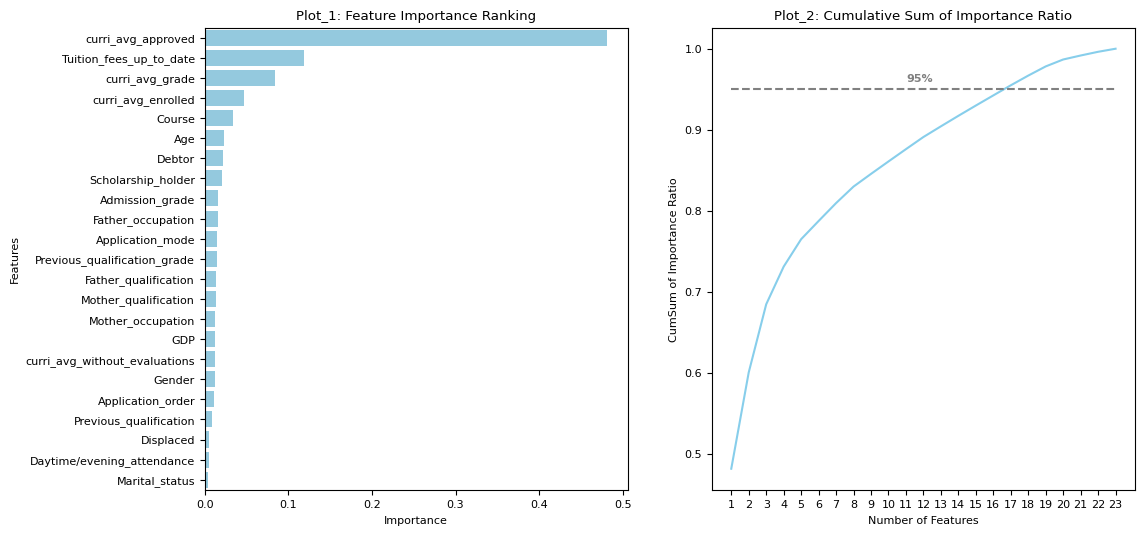

In [48]:
# Clasificación de importancia de las características del gráfico y suma acumulada de la razón de importancia
n = len(feature_imp)

fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 6))
ax1 = sns.barplot(data = feature_imp, x = 'Importance', y = 'Features', color = 'skyblue', ax = ax1)
ax1.set_title('Plot_1: Feature Importance Ranking')

ax2.plot(range(1, n+1), feature_imp['cum_ratio'], color = 'skyblue')
ax2.plot(range(1, n+1), np.repeat(0.95, n), color = 'grey', linestyle = 'dashed')
ax2.text(11, 0.96, '95%', color = 'grey', fontweight = 'bold')
ax2.set_title('Plot_2: Cumulative Sum of Importance Ratio')
ax2.set_xlabel('Number of Features')
ax2.set_ylabel('CumSum of Importance Ratio')
ax2.set_xticks(range(1, len(feature_imp)+1), range(1, len(feature_imp)+1));

Plot_1 muestra la clasificación de importancia de las características, mientras que Plot_2 muestra la suma acumulada de las razones de importancia desde la primera hasta la última característica en la clasificación. Claramente, no todas las características son igualmente importantes, y algunas contribuyen muy poco en función del puntaje de importancia promedio. La línea discontinua gris en Plot_2 indica cuándo la suma acumulada de las razones de importancia alcanza el 95 % de la importancia total, lo que corresponde a 15 características.

En Plot_1, podemos ver que la característica n.° 15 es "Género" y su puntaje de importancia es casi idéntico al de "Orden de aplicación", la característica n.° 16, lo que indica que estas dos características son casi iguales en importancia.

Eliminaré las últimas cinco características y mantendré las primeras 16 para volver a entrenar el modelo.

**Tercera iteración de modelado (16 características, etiqueta binaria)**

In [49]:
# Eliminar las últimas cinco características del conjunto de entrenamiento y prueba
least_imp = feature_imp['Features'][-5:].to_list()
train_16X = train_bi_X.drop(columns = least_imp)
test_16X = test_bi_X.drop(columns = least_imp)

In [50]:
# Entrena un bosque aleatorio con 16 características
rf_b16 = RandomForestClassifier(class_weight = 'balanced', random_state = 48)

rf_b16.fit(train_16X, train_bi_y)

y_pred = rf_b16.predict(test_16X)
y_prob = rf_b16.predict_proba(test_16X)

rf_b16_accuracy = round(balanced_accuracy_score(test_bi_y, y_pred), 3)
rf_b16_f1score = round(f1_score(test_bi_y, y_pred), 3)
rf_b16_auc = round(roc_auc_score(test_bi_y, y_prob[:, 1]), 3)

print('rf_b16 Performance:')
print('Balanced Accuracy:', rf_b16_accuracy)
print('F1 Score:', rf_b16_f1score)
print('AUC score:', rf_b16_auc)

rf_b16 Performance:
Balanced Accuracy: 0.914
F1 Score: 0.903
AUC score: 0.954


In [51]:
# Entrena XGBClassifier con 16 funciones
xgb_b16 = XGBClassifier(enable_categorical = True, scale_pos_weight = 1.65,
                        importance_type = 'gain', random_state = 48)
xgb_b16.fit(train_16X, train_bi_y)

y_pred = xgb_b16.predict(test_16X)
y_prob = xgb_b16.predict_proba(test_16X)

xgb_b16_accuracy = round(balanced_accuracy_score(test_bi_y, y_pred), 3)
xgb_b16_f1score = round(f1_score(test_bi_y, y_pred), 3)
xgb_b16_auc = round(roc_auc_score(test_bi_y, y_prob[:, 1]), 3)

print('xgb_b16 performance:')
print('Balanced accuracy:', xgb_b16_accuracy)
print('F1 score:', xgb_b16_f1score)
print('AUC score:', xgb_b16_auc)

xgb_b16 performance:
Balanced accuracy: 0.913
F1 score: 0.899
AUC score: 0.955


In [52]:
# Combine los dos modelos en VotingClassifier
vc_b16 = VotingClassifier(estimators = [('rf', rf_b16), ('xgb', xgb_b16)], voting = 'soft')

vc_b16.fit(train_16X, train_bi_y)

y_pred = vc_b16.predict(test_16X)
y_prob = vc_b16.predict_proba(test_16X)

vc_b16_accuracy = round(balanced_accuracy_score(test_bi_y, y_pred), 3)
vc_b16_f1score = round(f1_score(test_bi_y, y_pred), 3)
vc_b16_auc = round(roc_auc_score(test_bi_y, y_prob[:, 1]), 3)

print('vc_b16 performance:')
print('Balanced accuracy:', vc_b16_accuracy)
print('F1 score:', vc_b16_f1score)
print('AUC score:', vc_b16_auc)

vc_b16 performance:
Balanced accuracy: 0.921
F1 score: 0.911
AUC score: 0.957


In [53]:
pd.DataFrame({
    'Model': ['rf_b16', 'xgb_b16', 'vc_b16'],
    'Balanced Accuracy': [rf_b16_accuracy, xgb_b16_accuracy, vc_b16_accuracy],
    'F1 Score': [rf_b16_f1score, xgb_b16_f1score, vc_b16_f1score],
    'AUC': [rf_b16_auc, xgb_b16_auc, vc_b16_auc]
})

,Model,Balanced Accuracy,F1 Score,AUC
0,rf_b16,0.914,0.903,0.954
1,xgb_b16,0.913,0.899,0.955
2,vc_b16,0.921,0.911,0.957


El clasificador de votación 'vc_b16' logró una precisión equilibrada de 0,93, una puntuación F1 de 0,921 y una puntuación AUC de 0,959, lo que lo convierte en el mejor modelo entre todos los que hemos creado.

# Resultados y análisis

Reunamos el rendimiento del mejor modelo en cada iteración y visualicemos los resultados.

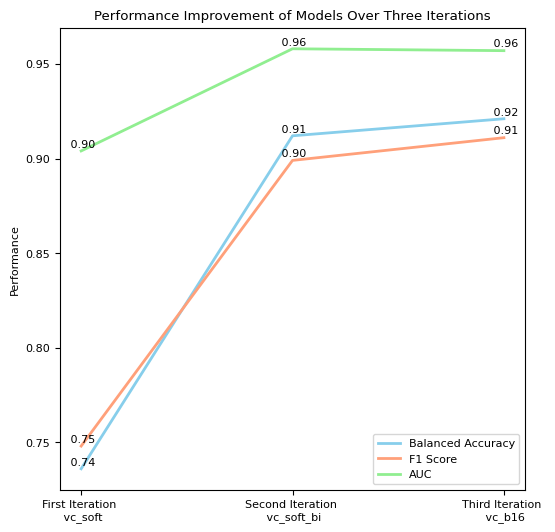

In [54]:
import warnings

# Suprimir mensajes FutureWarning
warnings.simplefilter(action='ignore', category=FutureWarning)

# Crear un marco de datos para el rendimiento del mejor modelo en cada iteración
results = pd.DataFrame({
    'Models': ['vc_soft', 'vc_soft_bi', 'vc_b16', 'vc_soft', 'vc_soft_bi',
               'vc_b16', 'vc_soft', 'vc_soft_bi', 'vc_b16'],
    'Metrics': ['Balanced Accuracy', 'Balanced Accuracy', 'Balanced Accuracy',
                'F1 Score', 'F1 Score', 'F1 Score', 'AUC', 'AUC', 'AUC'],
    'Performance': [vc_soft_accuracy, vc_soft_bi_accuracy, vc_b16_accuracy,
                    vc_soft_f1score, vc_soft_bi_f1score, vc_b16_f1score,
                    vc_soft_auc, vc_soft_bi_auc, vc_b16_auc]
})

# Visualice la mejora del rendimiento de los modelos en tres iteraciones
plt.figure(figsize = (6, 6))
xticks = range(len(results['Models'].unique()))
mods = ['First Iteration \n vc_soft', 'Second Iteration \n vc_soft_bi', 'Third Iteration \n vc_b16']
ax = sns.lineplot(data = results, x = 'Models', y = 'Performance', hue = 'Metrics',
                  palette = ['skyblue', 'lightsalmon', 'lightgreen'], linewidth = 2)
ax.set_xticks(xticks)
ax.set_xticklabels(mods)
ax.set_xlabel('')

for x, y in zip([0, 1, 2] * 3, results['Performance']):
    ax.text(x, y + 0.002, f'{y: .2f}', ha = 'center')

ax.set_title('Performance Improvement of Models Over Three Iterations')
ax.legend(title = '', loc = 'lower right');

A lo largo de tres iteraciones, con números de clase en evolución (de 3 a binario) y conjuntos de características (de 21 a 16), el rendimiento del modelo mejoró significativamente. La precisión equilibrada aumentó de 0,75 a 0,93 (un aumento del 24 %), la puntuación F1 aumentó de 0,76 a 0,92 (un aumento del 21 %) y el AUC aumentó de 0,91 a 0,96 (un aumento del 5 %), lo que indica mejoras sustanciales en la precisión de la clasificación.

Nuestro modelo final es "vc_b16".

**Visualización de las principales características en el modelo final**

Ahora examinemos la importancia de las características del modelo final, "vc_b16".

In [55]:
# Calcule el puntaje de importancia y normalice s3 para que sume 1 como lo hice antes
s1 = rf_b16.feature_importances_
s2 = xgb_b16.feature_importances_
s3 = permutation_importance(vc_b16, test_16X, test_bi_y, n_repeats = 10, random_state = 20).importances_mean
s3 = s3 / np.sum(s3)

imp = pd.DataFrame({
    'Features': test_16X.columns,
    'Importance': (s1 + s2 + s3)/3
})

imp = imp.sort_values(by = 'Importance', ascending = False)

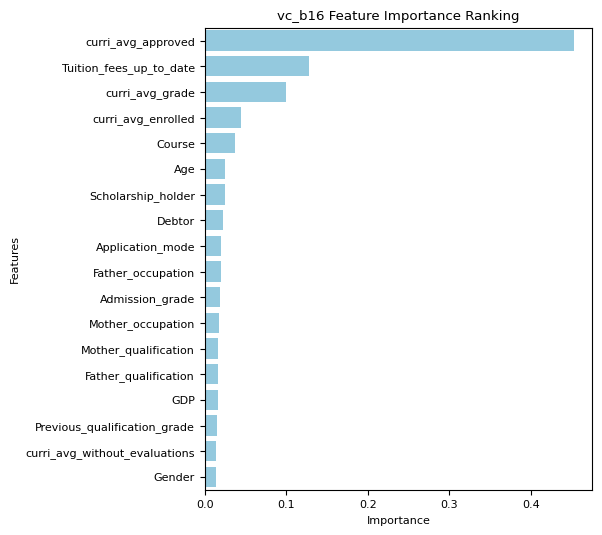

In [56]:
# Graficar la clasificación de importancia de las características
plt.figure(figsize = (5, 6))
sns.barplot(data = imp, x = 'Importance', y = 'Features', color = 'skyblue')
plt.title('vc_b16 Feature Importance Ranking');

Las características más importantes son 'curri_avg_approved', 'Tuition_fees_up_to_date' y 'curri_avg_grade', seguidas de 'curri_avg_enrolled', 'Course' y 'Age'. Entre estas características principales, cuatro son datos académicos, una es datos socioeconómicos y una es datos demográficos.

Veamos cómo estas características influyen en si los estudiantes abandonan o se gradúan.

In [57]:
# Extraer las características necesarias de todo el conjunto de datos para su posterior análisis.
cols = train_16X.columns.to_list()
cols.append('Target_encoded')

stud = stud_selected.loc[:, cols]
stud['Target_encoded'] = stud['Target_encoded'].replace([0, 1, 2], ['Drop Out', 'Enrolled', 'Graduate'])
stud['Gender'] = stud['Gender'].replace([0, 1], ['Female', 'Male'])
stud['Tuition_fees_up_to_date'] = stud['Tuition_fees_up_to_date'].replace([0, 1], ['No', 'Yes'])
stud.rename(columns = {'Target_encoded': 'Target'}, inplace = True)

# Reemplazar los valores del curso con el nombre del curso
stud['Course'] = stud['Course'].replace(list(range(1, 18)), ['Biofuel Production Technologies', 'Animation and Multimedia Design', 'Social Service (evening attendance)',
                                                              'Agronomy', 'Communication Design', 'Veterinary Nursing', 'Informatics Engineering', 'Equiniculture',
                                                              'Management', 'Social Service', 'Tourism', 'Nursing', 'Oral Hygiene', 'Advertising and Marketing Management',
                                                              'Journalism and Communication', 'Basic Education', 'Management (evening attendance)'])

Ya hemos observado cómo 'curri_avg_approved' y 'curri_avg_grade' se asocian con las situaciones de los estudiantes ('Dropout', 'Enrolled', o 'Graduate') al final del curso durante el Análisis de Datos Exploratorios. Ahora, examinemos las tres variables importantes relacionadas con las unidades curriculares, centrándonos únicamente en las dos etiquetas, 'Dropout' y 'Graduate'.

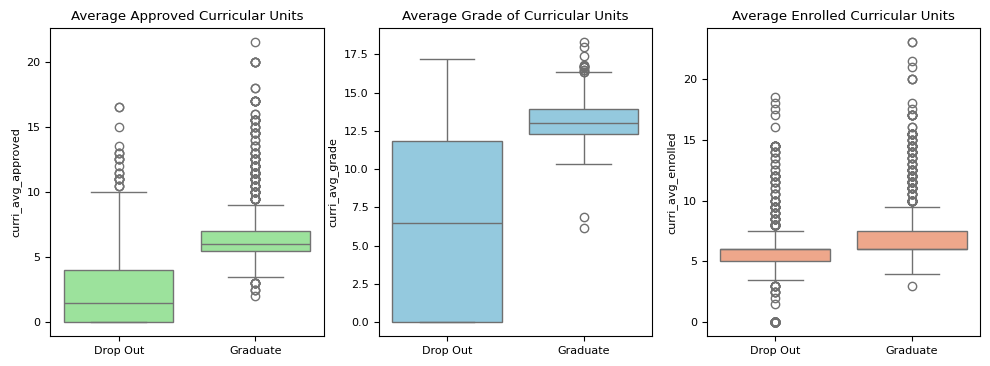

In [58]:
# Graficar las variables relacionadas de las tres unidades curriculares
fig, (ax1, ax2, ax3) = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 4))
sns.boxplot(data = stud.loc[(stud['Target'] == 'Drop Out') | (stud['Target'] == 'Graduate')],
            x = 'Target', y = 'curri_avg_approved', color = 'lightgreen', ax = ax1)
ax1.set_title('Average Approved Curricular Units')
ax1.set_xlabel("")

sns.boxplot(data = stud.loc[(stud['Target'] == 'Drop Out') | (stud['Target'] == 'Graduate')],
            x = 'Target', y = 'curri_avg_grade', color = 'skyblue', ax = ax2)
ax2.set_title('Average Grade of Curricular Units')
ax2.set_xlabel("")

sns.boxplot(data = stud.loc[(stud['Target'] == 'Drop Out') | (stud['Target'] == 'Graduate')],
            x = 'Target', y = 'curri_avg_enrolled', color = 'lightsalmon', ax = ax3)
ax3.set_title('Average Enrolled Curricular Units')
ax3.set_xlabel("");

Los estudiantes que se gradúan al final de la duración normal del curso tienen muchas más unidades curriculares aprobadas y una nota promedio mucho más alta en el primer y segundo semestre en comparación con los que abandonan.

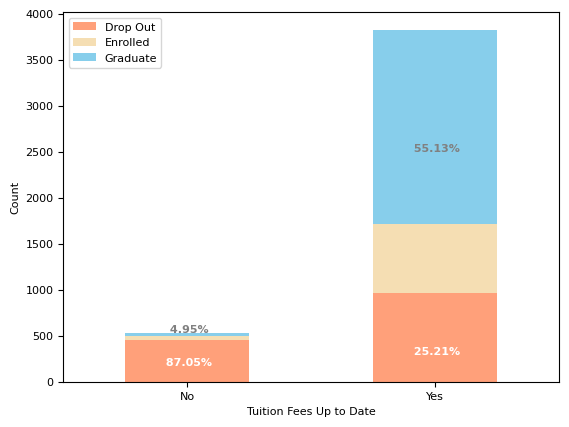

In [59]:
# Creamos la tabla cruzada de 'Tuition_fees_up_to_date' vs. 'Target'
tuition = pd.crosstab(stud['Tuition_fees_up_to_date'], stud['Target'])

# Normalizar la tabla cruzada para obtener el porcentaje
tuition_pct = tuition.div(tuition.sum(1), axis = 0) * 100

# Graficamos la tabla 'Tuition_fees_up_to_date' vs. 'Target'
tuition.plot(kind = 'bar', stacked = True, color = ['lightsalmon', 'wheat', 'skyblue'])
plt.legend(title = '')
plt.tick_params(axis = 'x', rotation = 0)
plt.ylabel('Count')
plt.xlabel('Tuition Fees Up to Date')
plt.text(0, 180, f"{tuition_pct.loc['No', 'Drop Out']: .2f}%", ha = 'center', color = 'white', fontweight = 'bold')
plt.text(0, 530, f"{tuition_pct.loc['No', 'Graduate']: .2f}%", ha = 'center', color = 'grey', fontweight = 'bold')
plt.text(1, 300, f"{tuition_pct.loc['Yes', 'Drop Out']: .2f}%", ha = 'center', color = 'white', fontweight = 'bold')
plt.text(1, 2500, f"{tuition_pct.loc['Yes', 'Graduate']: .2f}%", ha = 'center', color = 'grey', fontweight = 'bold');

Los estudiantes que no están al día con el pago de la matrícula tienen una tasa de deserción muy alta del 87,05% y una tasa de graduación muy baja del 4,95%.

La variable "Edad" varía de 17 a 70 en el conjunto de datos. La dividiré en cuatro grupos de edad y luego visualizaré la tasa de deserción por grupo de edad y género.

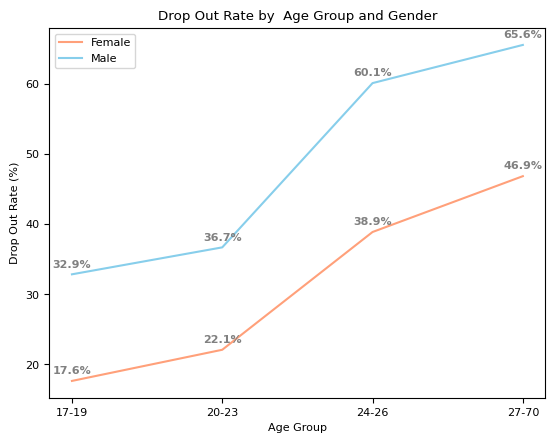

In [60]:
# Crear tablas cruzadas para diferentes grupos de edad vs. target
age17_19 = pd.crosstab(stud.loc[stud['Age'] < 20]['Gender'], stud.loc[stud['Age'] < 20]['Target'])
age17_19 = age17_19.div(age17_19.sum(1), axis = 0) * 100

age20_23 = pd.crosstab(stud.loc[(stud['Age'] > 19) & (stud['Age'] < 24)]['Gender'], stud.loc[(stud['Age'] > 19) & (stud['Age'] < 24)]['Target'])
age20_23 = age20_23.div(age20_23.sum(1), axis = 0) * 100

age24_26 = pd.crosstab(stud.loc[(stud['Age'] > 23) & (stud['Age'] < 27)]['Gender'], stud.loc[(stud['Age'] > 23) & (stud['Age'] < 27)]['Target'])
age24_26 = age24_26.div(age24_26.sum(1), axis = 0) * 100

age27_70 = pd.crosstab(stud.loc[stud['Age'] > 27]['Gender'], stud.loc[stud['Age'] > 27]['Target'])
age27_70 = age27_70.div(age27_70.sum(1), axis = 0) * 100

# Crear un marco de datos de la tasa de abandono escolar por grupo de edad y género
age_gen = pd.DataFrame({
    'Age Group': ['17-19', '17-19', '20-23', '20-23', '24-26', '24-26', '27-70', '27-70'],
    'Gender': ['Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male'],
    'Drop Out Rate (%)': [age17_19.loc['Female', 'Drop Out'], age17_19.loc['Male', 'Drop Out'],
                      age20_23.loc['Female', 'Drop Out'], age20_23.loc['Male', 'Drop Out'],
                      age24_26.loc['Female', 'Drop Out'], age24_26.loc['Male', 'Drop Out'],
                      age27_70.loc['Female', 'Drop Out'], age27_70.loc['Male', 'Drop Out']]
})

# Plot Drop Out Rate by  Age Group and Gende
ax = sns.lineplot(data = age_gen, x = 'Age Group', y = 'Drop Out Rate (%)',
                  hue = 'Gender', palette = ['lightsalmon', 'skyblue'])

for x, y in zip(age_gen['Age Group'], age_gen['Drop Out Rate (%)']):
    ax.text(x, y+1, f'{y:.1f}%', horizontalalignment = 'center', color = 'grey', fontweight = 'bold')

ax.set_title('Drop Out Rate by  Age Group and Gender')
ax.legend(title = '')
plt.show()

The dropout rates of both females and males increase with age, but females consistently have lower dropout rates across all age groups, suggesting that both age and gender are important factors influencing students' likelihood of dropping out.

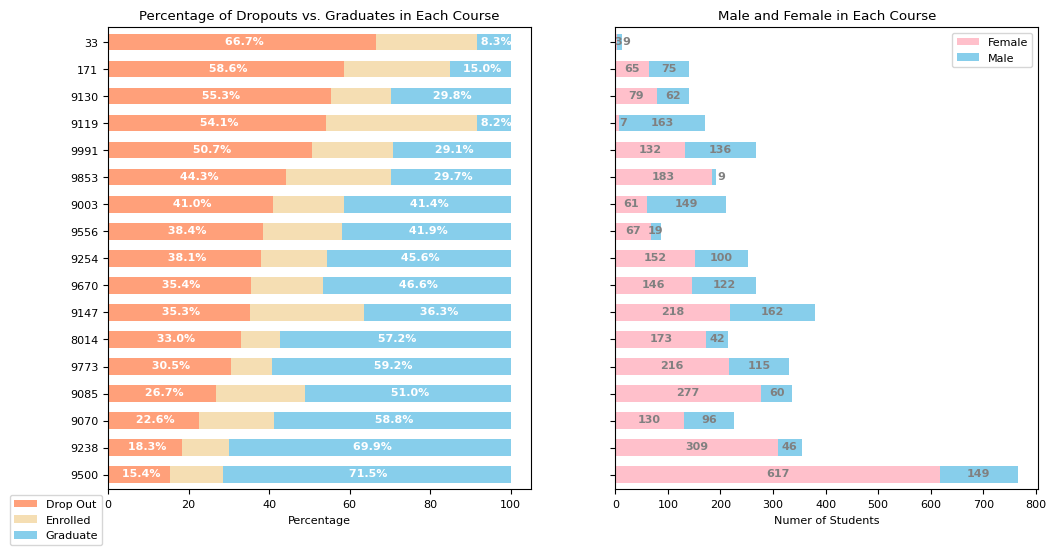

In [61]:
# Crear tabla cruzada de Curso vs. Target
course = pd.crosstab(stud['Course'], stud['Target'])

# Normalizar la tabla para obtener el porcentaje
course = course.div(course.sum(1), axis = 0) * 100

# Ordenar la tabla cruzada por 'Drop Out'
course = course.sort_values(by = 'Drop Out')

# Graficar el porcentaje de abandonos vs. graduados en cada curso
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 6), sharey = True)

colors = ['lightsalmon', 'wheat', 'skyblue']
course.plot(kind = 'barh', stacked = True, color = colors, width = 0.6, ax = ax1)
ax1.legend(title = '', bbox_to_anchor = (0, 0))
ax1.set_title('Percentage of Dropouts vs. Graduates in Each Course')
ax1.set_xlabel('Percentage')
ax1.set_ylabel('');

# Agregar etiquetas de porcentaje al gráfico
label_1 = list(range(0, 17))
label_3 = list(range(34, 52))
for i, p in enumerate(ax1.patches):
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if i in label_1:
        ax1.annotate(f'{width: .1f}%', (x + width/2, y + height/2.5), ha = 'center', color = 'white', fontweight = 'bold')
    elif i in label_3:
        ax1.annotate(f'{width: .1f}%', (x + width/2, y + height/2.5), ha = 'center', color = 'white', fontweight = 'bold')

# Contar el número de mujeres y hombres en cada curso.
num_stud = pd.crosstab(stud['Course'], stud['Gender']).reindex(course.index.to_list())

# Traza el número de estudiantes en cada curso
num_stud.plot(kind = 'barh', stacked = True, color = ['pink', 'skyblue'], width = 0.6, ax = ax2)
for p in ax2.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if width < 10:
        ax2.annotate(f'{int(width)}', (x + width * 2, y + height/2.5), ha = 'center', color = 'grey', fontweight = 'semibold')
    else:
        ax2.annotate(f'{int(width)}', (x + width/2, y + height/2.5), ha = 'center', color = 'grey', fontweight = 'semibold')

ax2.legend(title = '')
ax2.set_ylabel('')
ax2.set_xlabel('Numer of Students')
ax2.set_title('Male and Female in Each Course')

plt.show()

Las tasas de abandono en diferentes cursos varían entre el 15,4% y el 66,7%. Cinco de los 17 cursos tienen tasas de abandono superiores al 50%.

En este conjunto de datos, hay más mujeres que hombres, lo que da como resultado un predominio de estudiantes mujeres en la mayoría de los cursos. Si bien las inscripciones varían en los diferentes cursos, las proporciones de estudiantes mujeres y hombres también difieren, lo que sugiere que hay factores más allá del género que contribuyen a las tasas de abandono.

**Probabilidad de abandono en el conjunto de datos simulado**

Simularé tres conjuntos de datos: "calificación", "aprobado" y "edad", y predeciré la probabilidad de abandono utilizando el modelo final. Esto me permitirá ver cómo los valores de "curri_avg_grade", "curri_avg_approved" y "Age" afectan la probabilidad de abandono, mientras se mantienen constantes todas las demás características (tomando la media para los datos numéricos y la moda para los datos categóricos).

In [62]:
# Conjunto de datos simulado -- 'grade'
grade = pd.DataFrame({
    'Application_mode': np.repeat(stud_selected['Application_mode'].mode()[0], 84),
    'Application_order': np.repeat(stud_selected['Application_order'].mode()[0], 84),
    'Course': np.repeat(stud_selected['Course'].mode()[0], 84),
    'Mother_qualification': np.repeat(stud_selected['Mother_qualification'].mode()[0], 84),
    'Father_qualification': np.repeat(stud_selected['Father_qualification'].mode()[0], 84),
    'Mother_occupation': np.repeat(stud_selected['Mother_occupation'].mode()[0], 84),
    'Father_occupation': np.repeat(stud_selected['Father_occupation'].mode()[0], 84),
    'Debtor': np.repeat(stud_selected['Debtor'].mode()[0], 84),
    'Tuition_fees_up_to_date': np.repeat([0, 0, 1, 1], 21),
    'Gender': np.repeat([0, 1, 0, 1], 21),
    'Scholarship_holder': np.repeat(stud_selected['Scholarship_holder'].mode()[0], 84),
    'Age': np.repeat(round(stud_selected['Age'].mean()), 84),
    'GDP': np.repeat(stud_selected['GDP'].mean(), 84),
    'curri_avg_enrolled': np.repeat(round(stud_selected['curri_avg_enrolled'].mean()), 84),
    'curri_avg_approved': np.repeat(round(stud_selected['curri_avg_approved'].mean()), 84),
    'curri_avg_grade': list(range(0, 21)) * 4
})

# Predecir la probabilidad de abandono
grade['dropout_proba'] = vc_b16.predict_proba(grade)[:, 1]

# Modificar la tabla
grade['Gender'] = grade['Gender'].replace([1, 0], ['Male', 'Female'])
grade['Tuition_fees_up_to_date'] = grade['Tuition_fees_up_to_date'].replace([1, 0], ['Tuition_up_to_date', 'Tuition_NOT_up_to_date'])
grade['Gen_Tui'] = grade[['Gender', "Tuition_fees_up_to_date"]].agg('_'.join, axis = 1)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Application_order
Feature names seen at fit time, yet now missing:
- Admission_grade
- Previous_qualification_grade
- curri_avg_without_evaluations


In [ ]:
# Conjunto de datos simulado - 'aprobado'
approved = pd.DataFrame({
    'Application_mode': np.repeat(stud_selected['Application_mode'].mode()[0], 104),
    'Application_order': np.repeat(stud_selected['Application_order'].mode()[0], 104),
    'Course': np.repeat(stud_selected['Course'].mode()[0], 104),
    'Mother_qualification': np.repeat(stud_selected['Mother_qualification'].mode()[0], 104),
    'Father_qualification': np.repeat(stud_selected['Father_qualification'].mode()[0], 104),
    'Mother_occupation': np.repeat(stud_selected['Mother_occupation'].mode()[0], 104),
    'Father_occupation': np.repeat(stud_selected['Father_occupation'].mode()[0], 104),
    'Debtor': np.repeat(stud_selected['Debtor'].mode()[0], 104),
    'Tuition_fees_up_to_date': np.repeat([0, 0, 1, 1], 26),
    'Gender': np.repeat([0, 1, 0, 1], 26),
    'Scholarship_holder': np.repeat(stud_selected['Scholarship_holder'].mode()[0], 104),
    'Age': np.repeat(round(stud_selected['Age'].mean()), 104),
    'GDP': np.repeat(stud_selected['GDP'].mean(), 104),
    'curri_avg_enrolled': np.repeat(round(stud_selected['curri_avg_enrolled'].mean()), 104),
    'curri_avg_approved': list(range(0, 26)) * 4,
    'curri_avg_grade': np.repeat(round(stud_selected['curri_avg_grade'].mean()), 104)
})

# Predecir la tasa de abandono escolar
approved['dropout_proba'] = vc_b16.predict_proba(approved)[:, 1]

# Modificar la tabla
approved['Gender'] = approved['Gender'].replace([1, 0], ['Male', 'Female'])
approved['Tuition_fees_up_to_date'] = approved['Tuition_fees_up_to_date'].replace([1, 0], ['Tuition_up_to_date', 'Tuition_NOT_up_to_date'])
approved['Gen_Tui'] = approved[['Gender', "Tuition_fees_up_to_date"]].agg('_'.join, axis = 1)

In [63]:
# Conjunto de datos simulado -- 'edad'
age = pd.DataFrame({
    'Application_mode': np.repeat(stud_selected['Application_mode'].mode()[0], 216),
    'Application_order': np.repeat(stud_selected['Application_order'].mode()[0], 216),
    'Course': np.repeat(stud_selected['Course'].mode()[0], 216),
    'Mother_qualification': np.repeat(stud_selected['Mother_qualification'].mode()[0], 216),
    'Father_qualification': np.repeat(stud_selected['Father_qualification'].mode()[0], 216),
    'Mother_occupation': np.repeat(stud_selected['Mother_occupation'].mode()[0], 216),
    'Father_occupation': np.repeat(stud_selected['Father_occupation'].mode()[0], 216),
    'Debtor': np.repeat(stud_selected['Debtor'].mode()[0], 216),
    'Tuition_fees_up_to_date': np.repeat([0, 0, 1, 1], 54),
    'Gender': np.repeat([0, 1, 0, 1], 54),
    'Scholarship_holder': np.repeat(stud_selected['Scholarship_holder'].mode()[0], 216),
    'Age': list(range(17, 71)) * 4,
    'GDP': np.repeat(stud_selected['GDP'].mean(), 216),
    'curri_avg_enrolled': np.repeat(round(stud_selected['curri_avg_enrolled'].mean()), 216),
    'curri_avg_approved': np.repeat(round(stud_selected['curri_avg_approved'].mean()), 216),
    'curri_avg_grade': np.repeat(round(stud_selected['curri_avg_grade'].mean()), 216)
})

# Predecir la tasa de abandono escolar
age['dropout_proba'] = vc_b16.predict_proba(age)[:, 1]

# Modificar la tabla
age['Gender'] = age['Gender'].replace([1, 0], ['Male', 'Female'])
age['Tuition_fees_up_to_date'] = age['Tuition_fees_up_to_date'].replace([1, 0], ['Tuition_up_to_date', 'Tuition_NOT_up_to_date'])
age['Gen_Tui'] = age[['Gender', "Tuition_fees_up_to_date"]].agg('_'.join, axis = 1)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Application_order
Feature names seen at fit time, yet now missing:
- Admission_grade
- Previous_qualification_grade
- curri_avg_without_evaluations


ValueError: Could not interpret value `dropout_proba` for `y`. An entry with this name does not appear in `data`.

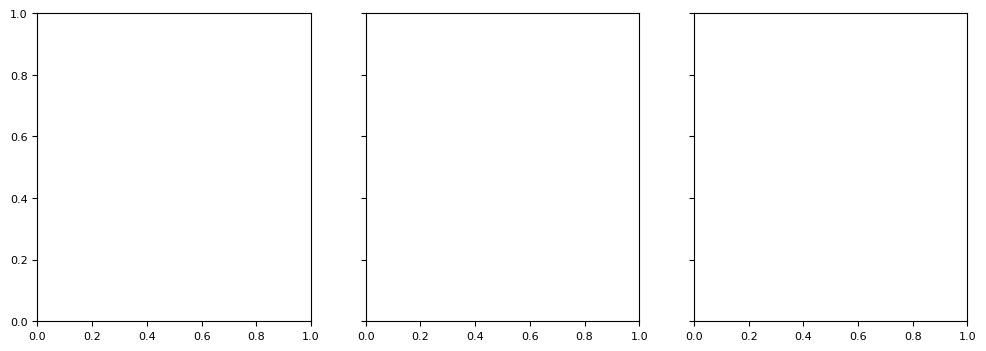

In [64]:
# Grafique la probabilidad de abandono en función de los tres conjuntos de datos simulados
fig, (ax1, ax2, ax3) = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 4), sharey = True)
plt.subplots_adjust(wspace = 0.2)
pal = ['salmon', 'lightgreen', 'pink', 'skyblue']

# Primer gráfico: 'Calificaciones promedio de las unidades curriculares en el 1er y 2do semestre'
sns.lineplot(data = grade, x = 'curri_avg_grade', y = 'dropout_proba', hue = 'Gen_Tui',
             linewidth = 2, palette = pal, legend = False, ax = ax1)

ax1.set_xlabel('Average Grades of Curricular Units')
ax1.set_ylabel('The Probability of Dropping Out')
ax1.set_yticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax1.plot(list(range(0,21)), np.repeat(0.5, 21), color = 'grey', linestyle = 'dashed');

# Segundo gráfico: 'Promedio de Unidades Curriculares Aprobadas en 1er y 2do Semestre'
sns.lineplot(data = approved, x = 'curri_avg_approved', y = 'dropout_proba', hue = 'Gen_Tui',
             linewidth = 2, palette = pal, legend = False, ax = ax2)

ax2.set_xlabel('Average Approved Curricular Units')
ax2.set_ylabel('')
ax2.plot(list(range(0,26)), np.repeat(0.5, 26), color = 'grey', linestyle = 'dashed');

# Tercera trama: 'La edad'
sns.lineplot(data = age, x = 'Age', y = 'dropout_proba', hue = 'Gen_Tui',
             linewidth = 2, palette = pal, ax = ax3)

ax3.legend(title = '', bbox_to_anchor = (1, 1))
ax3.set_ylabel('')
ax3.plot(list(range(17,71)), np.repeat(0.5, 54), color = 'grey', linestyle = 'dashed');

La probabilidad de abandono basada en los tres conjuntos de datos simulados muestra que "Tuition_fees_up_to_date" desempeña un papel vital en nuestro modelo final: los estudiantes cuyas tasas de matrícula NO están al día tienen una probabilidad de abandono significativamente mayor, que supera constantemente el 0,5 en la mayoría de los escenarios simulados.

Esto plantea otra pregunta: ¿un estudiante que no paga la matrícula a tiempo indica firmemente que es probable que abandone la escuela, o la universidad da de baja a los estudiantes de sus cursos cuando no han pagado todas las tasas de matrícula requeridas en las fechas límite especificadas? Probablemente ambas cosas. Pero esto está más allá de nuestro análisis.

Sin embargo, independientemente del factor de la tasa de matrícula, los gráficos muestran patrones claros de probabilidad de abandono:

* La probabilidad se mantiene en un nivel alto cuando la calificación promedio está entre 0 y 10, luego disminuye rápidamente a medida que la calificación promedio pasa de 10 a 13, y finalmente alcanza una meseta nuevamente más allá de eso;
* En el segundo gráfico se observan dos descensos bruscos, cuando el promedio de unidades curriculares aprobadas supera las 5 o las 14;
* La probabilidad se mantiene en un nivel bajo cuando la edad de matriculación de los estudiantes es inferior a 20 años, y luego aumenta rápidamente a medida que la edad pasa de 20 a 23 años, hasta alcanzar una meseta más allá de esa edad.

# Conclusión

**Resumen y hallazgos del proyecto**

En este proyecto, construí varios modelos de clasificación para predecir la deserción escolar y el éxito académico de los estudiantes. A lo largo de tres iteraciones de modelado, la complejidad del modelo se redujo de 21 características a 16 características y de la clasificación de tres clases a la binaria, mientras que el rendimiento del modelo mejoró significativamente:

* La precisión equilibrada aumentó de 0,75 a 0,93 (un aumento del 24 %)
* La puntuación F1 aumentó de 0,76 a 0,92 (un aumento del 21 %)
* El AUC aumentó de 0,91 a 0,96 (un aumento del 5 %)

A partir de estas tres iteraciones, aprendí que eliminar el ruido (como las características insignificantes y la clase de transición [en este caso, "Inscrito" que puede pasar a "Abandono" o "Graduado")) no solo reduce la complejidad del modelo, sino que también mejora significativamente el rendimiento del modelo, lo que da como resultado un modelo más simple y preciso.

Para examinar qué factores afectan la deserción estudiantil y cómo lo hacen, visualicé las características mejor clasificadas en el modelo final contra la variable objetivo y descubrí que:

* Los graduados tienden a tener un rendimiento académico significativamente más alto, como lo demuestra un mayor número de unidades curriculares aprobadas y calificaciones más altas en comparación con los que abandonan la escuela.
* Los estudiantes con matrículas impagas tienen muchas más probabilidades de abandonar la escuela (87,05 %) y menos probabilidades de graduarse (4,95 %) en comparación con los que pagan a tiempo (tasa de deserción: 25,21 %, tasa de graduación: 55,13 %).
* Las tasas de deserción aumentan con la edad tanto para mujeres como para hombres; sin embargo, las mujeres muestran sistemáticamente tasas de deserción más bajas en todos los grupos de edad.
* Las tasas de deserción en diferentes cursos varían del 15,4 % al 66,7 %. Cinco de los 17 cursos tienen tasas de deserción superiores al 50 %.

También exploré la probabilidad de abandono en tres conjuntos de datos simulados y descubrí que "Tuition_fees_up_to_date" desempeña un papel vital en nuestro modelo final, "vc_b16": los estudiantes cuyas tasas de matrícula NO están al día mostraron una probabilidad de abandono significativamente mayor, superando consistentemente el 0,5 en todos los escenarios simulados.

No estoy seguro de si el hecho de que un estudiante no pague la matrícula a tiempo es un indicador contundente de que es probable que abandone la carrera, o si la universidad da de baja a los estudiantes de sus cursos cuando no han pagado todas las tasas de matrícula requeridas en los plazos especificados. Sin embargo, independientemente del factor de la matrícula, los patrones de probabilidad de deserción son claros en los conjuntos de datos simulados:

* La probabilidad disminuye rápidamente a medida que la calificación promedio pasa de 10 a 13 o cuando el promedio de unidades curriculares aprobadas supera 5 y 14.
* La probabilidad aumenta rápidamente a medida que la edad de inscripción pasa de 20 a 23.

Esto sugiere que los estudiantes que se ajustan a estos perfiles pueden necesitar más apoyo para evitar la deserción:

* Las tasas de matrícula no están actualizadas;
* La calificación promedio en el 1.er y 2.º semestres es inferior a 10;
* El promedio de unidades curriculares aprobadas en el 1.er y 2.º semestres es inferior a 14, especialmente inferior a 5;
* La edad de inscripción es superior a 23 años.

Además, en las mismas circunstancias, los estudiantes varones y aquellos matriculados en cursos con altas tasas de deserción (superiores al 50%) también requieren más apoyo.

**Deficiencias e investigación futura**

Lo que no hice bien en este proyecto fue manejar datos categóricos de múltiples clases. Hay 10 variables de múltiples clases, la mayoría de las cuales tienen una cardinalidad alta, una distribución de categorías muy desigual y ningún orden inherente entre las categorías. Experimenté con tres métodos de codificación de características (codificación de frecuencia, codificación de objetivo K-fold y clasificación de categorías por sus puntuaciones de componentes principales) junto con la codificación de etiquetas original, lo que dio como resultado cuatro modelos con diferentes métodos de codificación de características y comparé su rendimiento. Los resultados fueron muy similares en todos los métodos. Después de examinar la importancia de permutación de las características en el modelo de Bosque aleatorio que utilicé para comparar diferentes resultados de codificación de características, descubrí que todas las variables de múltiples clases obtuvieron puntuaciones negativas o cercanas a cero, lo que sugiere que estas características no son importantes. Creo que esto explica por qué los diferentes métodos de codificación para las variables de múltiples clases no afectaron significativamente el rendimiento del modelo. Sin embargo, no eliminé todas las variables de múltiples clases, ya que el modelo aún no era óptimo y la clasificación de importancia de las características podría haber estado sesgada. Después de tres iteraciones de entrenamiento del modelo, algunas de las variables multiclase permanecieron en el modelo final.

Intenté comprender cómo estas variables afectan el abandono escolar de los estudiantes, pero no pude identificar un patrón claro. La tasa de abandono más alta a veces se da en la categoría "Desconocido". Además, algunas variables tienen demasiadas categorías y carezco del conocimiento del dominio y la experiencia local en Portugal para agruparlas o establecer un orden. En consecuencia, omití el análisis de la mayoría de las variables multiclase en comparación con las variables objetivo.

En futuras investigaciones, si el conocimiento del dominio se puede aprovechar para agrupar u ordenar estas categorías, o si se pueden emplear otras técnicas para descubrir patrones en la forma en que las variables multiclase se relacionan con el abandono escolar y el éxito académico, podrían surgir nuevos conocimientos.